In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# 표준화
from sklearn.preprocessing import MinMaxScaler
cancer = load_breast_cancer()
cancer_std = StandardScaler().fit_transform(cancer.data)
cancer_scaled = MinMaxScaler().fit_transform(cancer.data)

- 원본 데이터 정확도

In [ ]:
# 차원 축소 전 train, test 데이터 세팅
X_train, X_test, y_train, y_test = train_test_split(cancer_scaled, cancer.target, stratify = cancer.target, random_state = 2022)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

# 차원 축소 전
rfc = RandomForestClassifier(random_state=2022)

#학습
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=2022)

In [ ]:
# GridSearchCV
params = {'max_depth': [5,6,7], 'min_samples_split':[1,2,3]}

from sklearn.model_selection import GridSearchCV
grid_rf = GridSearchCV(rfc, params, scoring = 'accuracy', cv=5)
grid_rf.fit(X_train, y_train)

grid_rf.best_params_

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
15 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.7/dist-packages/sklearn/ensemble/_forest.py", line 467, in fit
    for i, t in enumerate(trees)
  File "/usr/local/lib/python3.7/dist-packages/joblib/parallel.py", line 1043, in __call__
    if self.dispatch_one_batch(iterator):
  File "/usr/local/lib/python3.7/dist-packages/joblib/para

{'max_depth': 5, 'min_samples_split': 2}

In [ ]:
# 원본 정확도 측정
best_rf = grid_rf.best_estimator_
best_rf.score(X_test, y_test)

0.9790209790209791

 - PCA를 이용하여 차원축소 후 정확도 확인

In [ ]:
# 학습시키는 코드
def pca_study(X,y):
  X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state=2022 )
  rfc = RandomForestClassifier(random_state=2022)
  rfc.fit(X_train, y_train)
  return rfc.score(X_test, y_test)

In [ ]:
# 차원 축소 정확도 측정 (2,5,10 차원)
for n in [2,5,10]:
  pca = PCA(n_components=n)
  cancer_pca = pca.fit_transform(cancer_std)
  explained = pca.explained_variance_ratio_.sum()
  acc = pca_study(cancer_pca, cancer.target)
  print(f'PCA{n}: 설명력-{explained: .4f}, 정확도-{acc: .4f}')

PCA2: 설명력- 0.6324, 정확도- 0.9580
PCA5: 설명력- 0.8473, 정확도- 0.9580
PCA10: 설명력- 0.9516, 정확도- 0.9371


In [ ]:
# 2차원
from sklearn.decomposition import PCA
pca2 = PCA(2)
cancer_pca2 = pca2.fit_transform(cancer.data)

In [ ]:
# 5차원
from sklearn.decomposition import PCA
pca5 = PCA(5)
cancer_pca5 = pca5.fit_transform(cancer.data)

In [ ]:
# 10차원
from sklearn.decomposition import PCA
pca10 = PCA(10)
cancer_pca10 = pca10.fit_transform(cancer.data)

차원 축소 정확도

In [ ]:
# 2차원으로 데이터로 축소
X_train, X_test, y_train, y_test = train_test_split(cancer_pca2, cancer.target, stratify = cancer.target, random_state=2022 )

rfc2 = RandomForestClassifier(random_state=2022)
rfc2.fit(X_train, y_train)
rfc2.score(X_test, y_test) # 평가

0.9230769230769231

In [ ]:
# 5차원으로 데이터로 축소
X_train, X_test, y_train, y_test = train_test_split(cancer_pca5, cancer.target, stratify = cancer.target, random_state=2022 )

rfc5 = RandomForestClassifier(random_state=2022)
rfc5.fit(X_train, y_train)
rfc5.score(X_test, y_test) # 평가

0.965034965034965

In [ ]:
# 10차원으로 데이터로 축소
X_train, X_test, y_train, y_test = train_test_split(cancer_pca10, cancer.target, stratify = cancer.target, random_state=2022 )

rfc10 = RandomForestClassifier(random_state=2022)
rfc10.fit(X_train, y_train)
rfc10.score(X_test, y_test) # 평가

0.972027972027972

In [ ]:
# Hard voting을 위한 앙상블 분류기
from sklearn.ensemble import VotingClassifier

voc = VotingClassifier([('RFC', rfc),('RFC2', rfc2),('RFC5', rfc5),('RFC10', rfc10)], voting = 'hard')

voc.fit(X_train, y_train) # 학습
voc.score(X_test, y_test) # 평가

0.972027972027972

군집화

In [ ]:
from sklearn.cluster import KMeans
KMeans().get_params()

{'algorithm': 'auto',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 8,
 'n_init': 10,
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [ ]:
# 2차원으로 축소한거 군집화

# 비지도 학습
kmeans = KMeans(n_clusters = 2, random_state=2022)
kmeans.fit(cancer_std)

# 결과
kmeans.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [ ]:
df = pd.DataFrame({'PC1':cancer_pca2[:,0], 'PC2':cancer_pca2[:,1],'target':cancer.target, 'cluster':kmeans.labels_})
df.head()


,PC1,PC2,target,cluster
0,1160.142574,-293.917544,0,1
1,1269.122443,15.630182,0,1
2,995.793889,39.156743,0,1
3,-407.180803,-67.380320,0,1
4,930.341180,189.340742,0,1


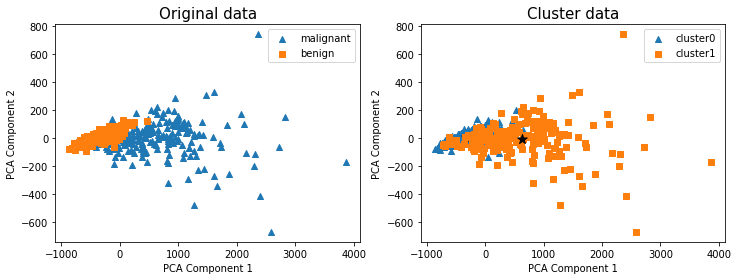

In [ ]:
#원본과 비교
markers = ['^','s']

plt.figure(figsize=(12,4))

for k, column in enumerate(['target','cluster']):
    plt.subplot(1, 2, k+1)

    for i, marker in enumerate(markers):
        x_data = df[df[column] == i]['PC1']
        y_data = df[df[column] == i]['PC2']

        if k == 0:
            plt.title('Original data', fontsize=15)
            plt.scatter(x_data, y_data, marker=marker, label=cancer.target_names[i])

        else:
            plt.title('Cluster data', fontsize=15)
            plt.scatter(x_data, y_data, marker=marker, label='cluster'+str(i))
            plt.scatter(x_data.mean(), y_data.mean(), marker='*', c='black', s=100)

    plt.legend()
    plt.xlabel('PCA Component 1'), plt.ylabel('PCA Component 2')

plt.show()